<font color="blue">**This notebook is used to train an SVR regressor on filter frequency response data to realize a synthesis tool for an arbitrary piecewise-continuous frequency response.**

1.   <font color="blue">It requires installation of PySPice library for analysis of a filter.

2. <font color="blue">Number of samples in frequency response is 129.

3. <font color="blue">Filter passband is from 2300MHz to 2400MHz.

4. <font color="blue">Filter frequency response is collected from 1800MHz to 2800MHz.

5. <font color="blue">Inductor values are uH ( micro-Henry) and capacitor values are in pF ( pico-Farad)

6. <font color="blue"> Trained SVR is saved and used to make prediction  for filter compnents when inputs is a piecewise continouous frequency reponse.  SVR design comapred to one derived using an optimization routine.

7. <font color="blue"> Hyperparamter search was done using Optuna library

<font color="blue">**Step 1:** First install PySpice and check that it is working corretly.

In [1]:
# First installed conda for PySpice installtion
# This could take up to 30 sec
!pip install condacolab
import condacolab
condacolab.install()
# NOTE: Colab will restart the kernel here. Run the next cell after it restarts.

  Using cached condacolab-0.1.10-py3-none-any.whl.metadata (5.5 kB)
Using cached condacolab-0.1.10-py3-none-any.whl (7.2 kB)
✨🍰✨ Everything looks OK!


In [ ]:
# Install ngspice packages, including executables & master package
# This could take 2-3 minutes
!conda install -c conda-forge ngspice-exe --quiet
!conda install -c conda-forge ngspice --quiet
!conda install -c conda-forge ngspice-lib --quiet

# Install pyspice using pip
!pip install -q pyspice

# This is optional: run this to ensure PySpice is installed
!pyspice-post-installation --check-install

# Install optuna if not present
!pip install -q optuna


<font color="blue">**Step 2:** Import all necessary libraries

In [3]:
#Import all needed libraries
#!/usr/bin/env python3

import sys
import os
import subprocess
import re
import copy
import random
import joblib
from collections import namedtuple
import numpy as np
from numpy._core.numerictypes import int32
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize
from sklearn.svm import LinearSVR, SVR
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

# Automatically install optuna if not found in current environment
try:
    import optuna
except ImportError:
    print("optuna not found. Installing in the current environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
    import optuna

import optuna.visualization as vis
import plotly.io as pio
# Set default renderer for Colab to display interactive plots
pio.renderers.default = 'colab'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

# Fix: PySpice was installed in python3.11 site-packages, add it to path if not present
if "/usr/local/lib/python3.11/site-packages" not in sys.path:
    sys.path.append("/usr/local/lib/python3.11/site-packages")
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from PySpice.Spice.NgSpice import Shared as NgSpiceShared
from PySpice.Spice.NgSpice.Shared import ffi



<font color="blue"> **Step 3:** Set config parameters and define methods for filter synthesis and frequency response analysis.

In [4]:
####### CONFIG PARAMETERS #########
# lowest value of frequency response
val_FR_lo=-65
# highest value of frequency response
val_FR_hi=5
# lowest frequency for plot
val_Freq_lo = 1800
# highest frequency for plot
val_Freq_hi = 2800
# number of points in frequency response of network
N_FreqResp=129
FreqVec_MHz=np.linspace(1800,2800,N_FreqResp)

# Calculate indices for the passband (2300 - 2400 MHz)
passband_indices = np.where((FreqVec_MHz >= 2300) & (FreqVec_MHz <= 2400))[0]

# in band max allowed in-band loss
max_inband_loss=-3

# These are in-band weights to ensure low IL in hte pass band and to avoid dominanc by OOB rejection
# for supervised learning
in_band_weight_SL = 1
# for Optimization
in_band_weight_Opt = 100

#-------------------------------------------------------------------------------
# Define method to AC simulate the synthesized network
# It only works for third order filters currenlty
def ACsim(L_nH,Cs_fF,Cp_fF,freqs_MHz, render_mode):
  # scale components
  L_uH =L_nH /1E3
  Cs_pF=Cs_fF/1E3
  Cp_pF=Cp_fF/1E3

  # 1. Define the Circuit
  circuit = Circuit('SynthNet')
  #print(L_uH, Cs_pF, Cp_PF)
  # AC voltage source: Define directly with SPICE string to ensure AC parameter is included
  # Syntax: V<name> <node+> <node-> 'DC <val> AC <val>'
  # add a small resistance to inductors to avoid singularity
  # source
  circuit.V(1,     'nodes',  circuit.gnd, 'DC 0 AC 1')
  # source impedance
  circuit.R(100,   'nodes',  'node1',        50@u_Ohm)
  # node 1 to GND shunt resonator
  circuit.L(0,     'node1',   'n1R',         L_uH[0]  @u_uH)
  circuit.R(800,   'n1R'  ,   'n1mid',       0.000001 @u_Ohm)
  circuit.C(800,   'n1mid',   circuit.gnd,   Cs_pF[0] @u_pF)
  circuit.C(900,   'node1',   circuit.gnd,   Cp_pF[0] @u_pF)
  # node 1 to node 2 series resoantor
  circuit.L(1,     'node1',   'n12R',        L_uH[1]  @u_uH)
  circuit.R(801,   'n12R'  ,  'n12mid',      0.000001 @u_Ohm)
  circuit.C(801,   'n12mid',  'node2',       Cs_pF[1] @u_pF)
  circuit.C(901,   'node1',   'node2',       Cp_pF[1] @u_pF)
  # node 2 to GND shunt resoantor
  circuit.L(2,     'node2',   'n2R',         L_uH[2]  @u_uH)
  circuit.R(802,   'n2R'  ,   'n2mid',       0.000001 @u_Ohm)
  circuit.C(802,   'n2mid',   circuit.gnd,   Cs_pF[2] @u_pF)
  circuit.C(902,   'node2',   circuit.gnd,   Cp_pF[2] @u_pF)
  # load impedance
  circuit.R(200,   'node2',  'nodel',        0.000001@u_Ohm)
  circuit.R(101,   'nodel',   circuit.gnd,   50@u_Ohm)

# Debug: Print the netlist
  #print("--- Generated Netlist ---")
  #print(circuit)

# 2. Setup Ngspice Simulator
# Use ID 0 for the standard system library
  FIXED_NGSPICE_ID = 0
# Check/Reuse existing Ngspice instance to avoid CDefError
  if FIXED_NGSPICE_ID in NgSpiceShared.NgSpiceShared._instances:
      ngspice_shared_instance = NgSpiceShared.NgSpiceShared._instances[FIXED_NGSPICE_ID]
  else:
    # Patch ffi.cdef to ignore duplicate declarations if necessary
    original_cdef = ffi.cdef
    def safe_cdef(csource, *args, **kwargs):
        try:
            original_cdef(csource, *args, **kwargs)
        except Exception as e:
            if "duplicate declaration" in str(e):
                pass
            else:
                raise e
    ffi.cdef = safe_cdef
    try:
        ngspice_shared_instance = NgSpiceShared.NgSpiceShared.new_instance(ngspice_id=FIXED_NGSPICE_ID)
    finally:
        ffi.cdef = original_cdef
# Create the simulator instance linked to the *current* circuit definition
  simulator = circuit.simulator(ngspice_shared=ngspice_shared_instance)

# 3. Run Analysis and Plot
  analysis = simulator.ac(start_frequency=freqs_MHz[0]*1E6@u_Hz, stop_frequency=freqs_MHz[-1]*1E6@u_Hz, number_of_points=np.size(freqs_MHz), variation='lin')
  # pick the load voltage
  v_out_mag = np.array(np.abs(analysis.nodes['nodel']))
  # find the magnitude of frequency response
  MagFreqResp= 20 * np.log10(2*v_out_mag)
  # print( MagFreqResp)
  if render_mode:
    # Plot in dB
    plt.plot(analysis.frequency/1E6, MagFreqResp)
    plt.title("AC Frequency Response")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Voltage at Node 2 (dB)")
    plt.grid(True, which="both")
    plt.show()

  # Memory cleanup for ngspice
  ngspice_shared_instance.exec_command('destroy all')
  ngspice_shared_instance.exec_command('remcirc')

  return MagFreqResp

<font color="blue"> **Step 4:** Upload training data

In [5]:
# Use this cell to input data needed for SVR training
#
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Set random seeds for reproducibility
import random
random.seed(42)

# Load Data
# Update the path if your file is located in a different folder within your Drive.
df = pd.read_csv('/content/drive/MyDrive/Data/simulation_results_small_cleaned.csv')

# Identify Input (Frequency Response) and Output (Component Values) columns
# Outputs: L, Cs, Cp columns
output_cols = [c for c in df.columns if c.startswith(('L_', 'Cs_', 'Cp_'))]
# Inputs: Mag columns
input_cols = [c for c in df.columns if c.startswith('Mag_')]

print(f"Number of Input Features: {len(input_cols)}")
print(f"Number of Output Targets: {len(output_cols)}")


X_raw = df[input_cols].values.astype(np.float32)
# Apply log10 to the target variables to handle the wide dynamic range
y_raw = np.log10(df[output_cols].values.astype(np.float32))


# Split Data (90% Train, 10% Test)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.10, random_state=42
)

print(f"Number of Training Samples: {len(X_train_raw)}")
print(f"Number of Test Samples: {len(X_test_raw)}")

# Scale Data (Standardization is crucial for MLP convergence)
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.base import BaseEstimator, TransformerMixin

scaler_X = StandardScaler()

# Create a Custom Scaler to apply QuantileTransformer to specific columns and StandardScaler to the rest
class MixedScaler(BaseEstimator, TransformerMixin):
    def __init__(self, quantile_idx, standard_idx):
        self.quantile_idx = quantile_idx
        self.standard_idx = standard_idx
        self.scaler_q = QuantileTransformer(output_distribution='normal', random_state=42)
        self.scaler_s = StandardScaler()

    def fit(self, X, y=None):
        # Ensure X is numpy array
        X_np = np.asarray(X)
        # Create temporary full array for fitting, preserving order
        temp_q_data = X_np[:, self.quantile_idx]
        temp_s_data = X_np[:, self.standard_idx]

        if temp_q_data.shape[1] > 0: # Only fit if there are quantile columns
            self.scaler_q.fit(temp_q_data)
        if temp_s_data.shape[1] > 0: # Only fit if there are standard columns
            self.scaler_s.fit(temp_s_data)

        self.n_features_in_ = X_np.shape[1]
        return self

    def transform(self, X):
        X_np = np.asarray(X)
        X_trans = np.zeros_like(X_np, dtype=float)

        if len(self.quantile_idx) > 0: # Only transform if there are quantile columns
            X_trans[:, self.quantile_idx] = self.scaler_q.transform(X_np[:, self.quantile_idx])
        if len(self.standard_idx) > 0: # Only transform if there are standard columns
            X_trans[:, self.standard_idx] = self.scaler_s.transform(X_np[:, self.standard_idx])
        return X_trans

    def inverse_transform(self, X):
        X_np = np.asarray(X)
        X_inv = np.zeros_like(X_np, dtype=float)

        if len(self.quantile_idx) > 0: # Only inverse transform if there are quantile columns
            X_inv[:, self.quantile_idx] = self.scaler_q.inverse_transform(X_np[:, self.quantile_idx])
        if len(self.standard_idx) > 0: # Only inverse transform if there are standard columns
            X_inv[:, self.standard_idx] = self.scaler_s.inverse_transform(X_np[:, self.standard_idx])
        return X_inv

# Identify indices for Quantile vs Standard scaling
quantile_cols = ['Cp_1'] # Only use Quantile for Cp_1
quantile_idx = [output_cols.index(c) for c in quantile_cols]
standard_idx = [i for i, c in enumerate(output_cols) if c not in quantile_cols]

# Initialize the custom scaler for targets
scaler_y = MixedScaler(quantile_idx, standard_idx)

# Fit on training data only to avoid leakage
X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

# Transform test data
X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

##################################
# ---  Apply In-Band Weighting ---
##################################

print(f"Applying in-band weight of {in_band_weight_SL} to frequencies between 2300MHz and 2400MHz.")

# Find column indices for frequencies in the passband (2300 - 2400 MHz)
in_band_indices = []
for i, col in enumerate(input_cols):
    # Extract numeric frequency from column name like 'Mag_2300.00MHz'
    freq = float(col.replace('Mag_', '').replace('MHz', ''))
    if 2300.0 <= freq <= 2400.0:
        in_band_indices.append(i)

# Apply the weight AFTER scaling so StandardScaler doesn't cancel it out
X_train_scaled[:, in_band_indices] *= in_band_weight_SL
X_test_scaled[:, in_band_indices] *= in_band_weight_SL

display(df.head(20))


Mounted at /content/drive
Number of Input Features: 129
Number of Output Targets: 9
Number of Training Samples: 5395
Number of Test Samples: 600
Applying in-band weight of 1 to frequencies between 2300MHz and 2400MHz.


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2,Mag_1800.00MHz,...,Mag_2729.69MHz,Mag_2737.50MHz,Mag_2745.31MHz,Mag_2753.12MHz,Mag_2760.94MHz,Mag_2768.75MHz,Mag_2776.56MHz,Mag_2784.38MHz,Mag_2792.19MHz,Mag_2800.00MHz
0,0.1639,88.58,0.1639,7.115404e+06,51.8,1.252603e+07,29278,145,28177,-51.564003,...,-78.924077,-109.345099,-79.303122,-73.856148,-70.812280,-68.760914,-67.253007,-66.087253,-65.155941,-64.394693
1,0.1639,88.58,0.1639,1.091239e+07,51.8,1.046144e+07,28311,318,28442,-47.397272,...,-43.835646,-43.961716,-44.090729,-44.222144,-44.355494,-44.490378,-44.626448,-44.763400,-44.900973,-45.038939
2,0.1639,88.58,0.1639,7.473066e+06,51.8,4.111292e+06,27199,297,29078,-48.230940,...,-44.191564,-44.309525,-44.431560,-44.556974,-44.685167,-44.815628,-44.947913,-45.081640,-45.216476,-45.352134
3,0.1639,88.58,0.1639,7.518186e+06,51.8,1.291216e+07,28479,681,27586,-42.195290,...,-33.877630,-34.115003,-34.348387,-34.577875,-34.803559,-35.025530,-35.243876,-35.458687,-35.670048,-35.878043
4,0.1639,88.58,0.1639,1.013440e+07,51.8,4.715176e+06,28112,60,28992,-55.174670,...,-49.277532,-49.892865,-50.500556,-51.101086,-51.694915,-52.282488,-52.864233,-53.440569,-54.011898,-54.578617
5,0.1639,88.58,0.1639,7.245827e+06,51.8,4.849310e+06,28155,605,27384,-43.496264,...,-34.401097,-34.642754,-34.880378,-35.114055,-35.343872,-35.569914,-35.792270,-36.011024,-36.226260,-36.438062
6,0.1639,88.58,0.1639,6.327330e+06,51.8,1.139232e+07,28169,470,27334,-45.312248,...,-37.153280,-37.373410,-37.590767,-37.805332,-38.017098,-38.226068,-38.432251,-38.635667,-38.836337,-39.034290
7,0.1639,88.58,0.1639,4.139958e+06,51.8,1.476130e+07,28305,374,27605,-46.814225,...,-40.464532,-40.644869,-40.824814,-41.004139,-41.182651,-41.360188,-41.536613,-41.711813,-41.885693,-42.058174
8,0.1639,88.58,0.1639,1.344955e+07,51.8,1.216149e+07,28149,510,28307,-44.196204,...,-37.363028,-37.573329,-37.781057,-37.986194,-38.188736,-38.388686,-38.586054,-38.780855,-38.973112,-39.162847
9,0.1639,88.58,0.1639,1.241205e+07,51.8,4.529768e+06,28009,677,27626,-42.529555,...,-33.430710,-33.675623,-33.916274,-34.152768,-34.385211,-34.613706,-34.838354,-35.059255,-35.276505,-35.490198


<font color="blue"> **Step 5:** Train SVR and save the results to a file

In [12]:
X_train_np = X_train_scaled
y_train_np = y_train_scaled
X_test_np = X_test_scaled
y_test_np = y_test_scaled

# --- Subsample the training data ---
n_samples = 4500
np.random.seed(42)
subsample_indices = np.random.choice(X_train_np.shape[0], n_samples, replace=False)
X_train_sub = X_train_np[subsample_indices]
y_train_sub = y_train_np[subsample_indices]

print(f"\nTraining on a subsample of {n_samples} with Nystroem Kernel Approximation...")

svr_models = []
start_time_svr = time.time()

for i, col_name in enumerate(output_cols):
    print(f"\n--- Training Target {i+1}/{len(output_cols)}: {col_name} ---")

    # Isolate the target column
    target_train = y_train_sub[:, i]

    if col_name in ['Cp_1']:
        # Concentrate heavily with a direct, strong RBF SVR
        print(f"    [Applying concentrated RBF SVR for {col_name}]")
        model = SVR(kernel='rbf', C=100.0, epsilon=0.01, gamma='scale')
    else:
        # Pipeline: Nystroem approximation followed by a fast LinearSVR for other components
        nystroem = Nystroem(kernel='rbf', gamma=None, n_components=800, random_state=42)
        linear_svr = LinearSVR(C=1.529956, epsilon=1.132946e-02, verbose=1, max_iter=50000)
        model = make_pipeline(nystroem, linear_svr)

    # Fit the model
    t0 = time.time()
    model.fit(X_train_sub, target_train)
    t1 = time.time()

    # Store the trained model
    svr_models.append(model)

    # Predict to calculate interim MAPE
    pred_train_scaled = model.predict(X_train_sub)
    pred_test_scaled = model.predict(X_test_np)

    # Create dummy arrays to use the global scaler_y for inverse transform
    dummy_train = np.zeros((len(pred_train_scaled), y_train_np.shape[1]))
    dummy_train[:, i] = pred_train_scaled
    pred_train_log = scaler_y.inverse_transform(dummy_train)[:, i]

    dummy_test = np.zeros_like(y_test_np)
    dummy_test[:, i] = pred_test_scaled
    pred_test_log = scaler_y.inverse_transform(dummy_test)[:, i]

    # Get raw physical values
    true_train_raw = 10**(y_train_raw[subsample_indices, i])
    true_test_raw = 10**(y_test_raw[:, i])

    pred_train_raw = 10**pred_train_log
    pred_test_raw = 10**pred_test_log

    # Calculate MAPE
    mape_train = np.mean(np.abs((true_train_raw - pred_train_raw) / (np.abs(true_train_raw) + 1e-8))) * 100
    mape_test = np.mean(np.abs((true_test_raw - pred_test_raw) / (np.abs(true_test_raw) + 1e-8))) * 100

    print(f"    Completed in {t1-t0:.2f}s | Train MAPE (subsample): {mape_train:.4f}% | Test MAPE: {mape_test:.4f}%")

end_time_svr = time.time()
print(f"\nSVR full training completed in {(end_time_svr - start_time_svr):.2f} seconds.")

# Create a wrapper class to mimic MultiOutputRegressor behavior for subsequent cells
class CustomMultiOutputSVR:
    def __init__(self, models):
        self.estimators_ = models
    def predict(self, X):
        return np.column_stack([m.predict(X) for m in self.estimators_])

svr_model = CustomMultiOutputSVR(svr_models)

# Evaluate Overall SVR on Test Set
y_pred_svr_scaled = svr_model.predict(X_test_np)
y_pred_svr_log = scaler_y.inverse_transform(y_pred_svr_scaled)
y_test_log = scaler_y.inverse_transform(y_test_np)

y_pred_svr_raw = 10**y_pred_svr_log
y_test_eval_raw = 10**y_test_log

mape_svr_test = np.mean(np.abs((y_test_eval_raw - y_pred_svr_raw) / (np.abs(y_test_eval_raw) + 1e-8))) * 100

# Evaluate Overall SVR on Full Training Set
y_pred_train_svr_scaled = svr_model.predict(X_train_np)
y_pred_train_svr_log = scaler_y.inverse_transform(y_pred_train_svr_scaled)
y_train_log = scaler_y.inverse_transform(y_train_np)

y_pred_train_svr_raw = 10**y_pred_train_svr_log
y_train_eval_raw = 10**y_train_log

mape_svr_train = np.mean(np.abs((y_train_eval_raw - y_pred_train_svr_raw) / (np.abs(y_train_eval_raw) + 1e-8))) * 100

print(f"\nOverall SVR Train MAPE (on raw component values): {mape_svr_train:.4f}%")
print(f"Overall SVR Test MAPE (on raw component values): {mape_svr_test:.4f}%")



Training on a subsample of 4500 with Nystroem Kernel Approximation...

--- Training Target 1/9: L_0 ---
[LibLinear]    Completed in 13.94s | Train MAPE (subsample): 0.2418% | Test MAPE: 0.2841%

--- Training Target 2/9: L_1 ---
[LibLinear]    Completed in 8.69s | Train MAPE (subsample): 0.0344% | Test MAPE: 0.0391%

--- Training Target 3/9: L_2 ---
[LibLinear]    Completed in 15.34s | Train MAPE (subsample): 0.2419% | Test MAPE: 0.2842%

--- Training Target 4/9: Cs_0 ---
[LibLinear]    Completed in 1.19s | Train MAPE (subsample): 32.1662% | Test MAPE: 32.4624%

--- Training Target 5/9: Cs_1 ---
[LibLinear]    Completed in 9.14s | Train MAPE (subsample): 0.0337% | Test MAPE: 0.0384%

--- Training Target 6/9: Cs_2 ---
[LibLinear]    Completed in 0.82s | Train MAPE (subsample): 31.7321% | Test MAPE: 33.4087%

--- Training Target 7/9: Cp_0 ---
[LibLinear]    Completed in 4.88s | Train MAPE (subsample): 1.0729% | Test MAPE: 1.2558%

--- Training Target 8/9: Cp_1 ---
    [Applying concentra

<font color="blue"> **Step 6:** Find average MAPE for training and test data

In [13]:
print("Calculating MAPE on the full Training and Test datasets for individual components...")

# ---- Training Set Evaluation ----
# Get predictions for the full training set using the trained SVR model
train_preds_scaled = svr_model.predict(X_train_scaled)
# Inverse transform to get log10 physical units and then raw physical units
train_preds_raw = 10 ** scaler_y.inverse_transform(train_preds_scaled)
# Get original raw targets (y_train_raw is already in log10, so 10** to convert to raw)
train_target_raw = 10 ** y_train_raw

# Calculate overall and individual MAPE
train_mape_overall = np.mean(np.abs((train_target_raw - train_preds_raw) / (np.abs(train_target_raw) + 1e-8))) * 100
train_mape_individual = np.mean(np.abs((train_target_raw - train_preds_raw) / (np.abs(train_target_raw) + 1e-8)), axis=0) * 100

# ---- Test Set Evaluation ----
# Get predictions for the full test set
test_preds_scaled = svr_model.predict(X_test_scaled)
# Inverse transform to get log10 physical units and then raw physical units
test_preds_raw = 10 ** scaler_y.inverse_transform(test_preds_scaled)
# Get original raw targets (y_test_raw is already in log10, so 10** to convert to raw)
test_target_raw = 10 ** y_test_raw

# Calculate overall and individual MAPE
test_mape_overall = np.mean(np.abs((test_target_raw - test_preds_raw) / (np.abs(test_target_raw) + 1e-8))) * 100
test_mape_individual = np.mean(np.abs((test_target_raw - test_preds_raw) / (np.abs(test_target_raw) + 1e-8)), axis=0) * 100

print(f"\n=== Overall MAPE ===")
print(f"Average Training Set MAPE (Component Values): {train_mape_overall:.4f}%")
print(f"Average Test Set MAPE (Component Values): {test_mape_overall:.4f}%")

print(f"\n=== Individual Component MAPE ===")
# Create a DataFrame for nice formatting
mape_df = pd.DataFrame({
    'Component': output_cols,
    'Train MAPE (%)': train_mape_individual,
    'Test MAPE (%)': test_mape_individual
})
display(mape_df)


Calculating MAPE on the full Training and Test datasets for individual components...

=== Overall MAPE ===
Average Training Set MAPE (Component Values): 7.6901%
Average Test Set MAPE (Component Values): 7.9412%

=== Individual Component MAPE ===


,Component,Train MAPE (%),Test MAPE (%)
0,L_0,0.249091,0.284139
1,L_1,0.035416,0.039089
2,L_2,0.249131,0.284152
3,Cs_0,32.528383,32.462358
4,Cs_1,0.034718,0.038391
5,Cs_2,32.032254,33.408739
6,Cp_0,1.108726,1.255821
7,Cp_1,1.863493,2.434786
8,Cp_2,1.109777,1.263449


<font color="blue"> **Step 7:** Hyperparameter tuning (optional)

### Hyperparameter Tuning SVR using Optuna

Just like with the MLP,  use Optuna to find the best hyperparameters for  SVR model.  Focus is on key SVR parameters like `C`, `epsilon`, `gamma`, and potentially different `kernel` types.

In [11]:
# Set default renderer for Colab to display interactive plots
pio.renderers.default = 'colab'

# Find the index for Cs_0
target_idx = output_cols.index('Cs_0')
print(f"Tuning specifically for target: {output_cols[target_idx]} (Index {target_idx})")

# Create a validation set for Optuna tuning from the training data
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.2, random_state=42
)

# Isolate the target column for Cs_0
y_opt_train_cs0 = y_opt_train[:, target_idx]
y_opt_val_cs0 = y_opt_val[:, target_idx]

print(f"Optuna Training Samples: {len(X_opt_train)}, Optuna Validation Samples: {len(X_opt_val)}")

# 2. Define the Objective Function for Optuna for SVR
def objective_svr(trial):
    # Search Space for kernel, C, and epsilon
    kernel_type = trial.suggest_categorical('kernel', ['liblinear', 'rbf'])
    C = trial.suggest_float('C', 0.1, 10.0, log=True)
    epsilon = trial.suggest_float('epsilon', 1e-2, 1e-1, log=True)

    # Initialize the corresponding model
    if kernel_type == 'liblinear':
        model = LinearSVR(C=C, epsilon=epsilon, max_iter=100000, random_state=42)
    else:
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
        model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)

    # Train the Model
    model.fit(X_opt_train, y_opt_train_cs0)

    # Evaluate the Model on the validation set
    y_pred_scaled = model.predict(X_opt_val)

    # Inverse transform predictions and actual values for MAPE calculation
    dummy_pred = np.zeros((len(y_pred_scaled), len(output_cols)))
    dummy_pred[:, target_idx] = y_pred_scaled
    y_pred_log = scaler_y.inverse_transform(dummy_pred)[:, target_idx]

    dummy_val = np.zeros((len(y_opt_val_cs0), len(output_cols)))
    dummy_val[:, target_idx] = y_opt_val_cs0
    y_val_log = scaler_y.inverse_transform(dummy_val)[:, target_idx]

    y_pred_raw = 10**y_pred_log
    y_val_raw = 10**y_val_log

    mape = np.mean(np.abs((y_val_raw - y_pred_raw) / (np.abs(y_val_raw) + 1e-8))) * 100

    # The objective value to minimize is the validation MAPE
    return mape

# 3. Create the Study and Optimize
print("Starting fast Optuna Hyperparameter Tuning for SVR (liblinear vs rbf) for Cs_0...")

tune_start_svr = time.time()
study_svr = optuna.create_study(direction='minimize', study_name="SVR_Hyperparameter_Tuning_Cs_0")

# Set n_trials to a lower number for a fast tuning run
study_svr.optimize(objective_svr, n_trials=20)
tune_duration_svr = time.time() - tune_start_svr

print(f"\nOptuna SVR Tuning for Cs_0 Completed in {tune_duration_svr:.2f} seconds!")


# Tuning Report
best_trial_svr = study_svr.best_trial

print("="*60)
print("🎯 OPTUNA SVR HYPERPARAMETER TUNING REPORT 🎯")
print("="*60)

print(f"Total combinations (trials) examined: {len(study_svr.trials)}")

print("\n📈 BEST SVR MAPE PERFORMANCE:")
print(f"  - Best Validation MAPE: {best_trial_svr.value:.6f}%")

print("\n🏆 BEST SVR HYPERPARAMETERS:")
for key, value in best_trial_svr.params.items():
    if isinstance(value, float):
        print(f"  - {key.upper()}: {value:.6e}")
    else:
        print(f"  - {key.upper()}: {value}")

print("="*60)

print("Generating Interactive Optuna Visualizations for SVR...")

import optuna.visualization as vis

# 1. Optimization History: Shows how the validation MAPE improved over trials
fig_svr1 = vis.plot_optimization_history(study_svr)
fig_svr1.show()

# 2. Parameter Importances: Shows which hyperparameter had the biggest impact on MAPE
fig_svr2 = vis.plot_param_importances(study_svr)
fig_svr2.show()

# 3. Parallel Coordinate Plot: Shows the relationships and combinations of high-performing parameters
fig_svr3 = vis.plot_parallel_coordinate(study_svr)
fig_svr3.show()

# 4. Slice Plot: Shows the distribution of each parameter against the objective value
fig_svr4 = vis.plot_slice(study_svr)
fig_svr4.show()

# 1. Save the trained SVR model
svr_model_save_path = '/content/drive/MyDrive/Data/svr_model.pkl'
joblib.dump(svr_model, svr_model_save_path)
print(f"SVR model successfully saved to '{svr_model_save_path}'")

# 2. Save the data scalers (if not already saved, or if you want to save specific versions)
scaler_x_path_svr = '/content/drive/MyDrive/Data/scaler_X_svr.pkl'
scaler_y_path_svr = '/content/drive/MyDrive/Data/scaler_y_svr.pkl'

joblib.dump(scaler_X, scaler_x_path_svr)
joblib.dump(scaler_y, scaler_y_path_svr)
print(f"Data scalers successfully saved to '{scaler_x_path_svr}' and '{scaler_y_path_svr}'")

# NOTE: To load them later, you would do:
# loaded_svr_model = joblib.load('/content/drive/MyDrive/Data/svr_model.pkl')
# loaded_scaler_X_svr = joblib.load('/content/drive/MyDrive/Data/scaler_X_svr.pkl')
# loaded_scaler_y_svr = joblib.load('/content/drive/MyDrive/Data/scaler_y_svr.pkl')


[I 2026-04-27 01:18:52,983] A new study created in memory with name: SVR_Hyperparameter_Tuning_Cs_0


Tuning specifically for target: Cs_0 (Index 3)
Optuna Training Samples: 4316, Optuna Validation Samples: 1079
Starting fast Optuna Hyperparameter Tuning for SVR (liblinear vs rbf) for Cs_0...


[I 2026-04-27 01:18:55,665] Trial 0 finished with value: 34.348974530483304 and parameters: {'kernel': 'liblinear', 'C': 1.5299562720015836, 'epsilon': 0.011329464061058935}. Best is trial 0 with value: 34.348974530483304.
[I 2026-04-27 01:18:57,655] Trial 1 finished with value: 34.47420017082925 and parameters: {'kernel': 'rbf', 'C': 0.39119501139886825, 'epsilon': 0.01863520432699161, 'gamma': 'scale'}. Best is trial 0 with value: 34.348974530483304.
[I 2026-04-27 01:18:59,731] Trial 2 finished with value: 34.75108041110951 and parameters: {'kernel': 'rbf', 'C': 2.0047033133358463, 'epsilon': 0.026985385954996787, 'gamma': 'auto'}. Best is trial 0 with value: 34.348974530483304.
[I 2026-04-27 01:19:02,848] Trial 3 finished with value: 34.47357005683679 and parameters: {'kernel': 'liblinear', 'C': 1.5213699404703651, 'epsilon': 0.06062263998843794}. Best is trial 0 with value: 34.348974530483304.
[I 2026-04-27 01:19:09,743] Trial 4 finished with value: 34.37349690959019 and parameters


Optuna SVR Tuning for Cs_0 Completed in 88.32 seconds!
🎯 OPTUNA SVR HYPERPARAMETER TUNING REPORT 🎯
Total combinations (trials) examined: 20

📈 BEST SVR MAPE PERFORMANCE:
  - Best Validation MAPE: 34.348975%

🏆 BEST SVR HYPERPARAMETERS:
  - KERNEL: liblinear
  - C: 1.529956e+00
  - EPSILON: 1.132946e-02
Generating Interactive Optuna Visualizations for SVR...


SVR model successfully saved to '/content/drive/MyDrive/Data/svr_model.pkl'
Data scalers successfully saved to '/content/drive/MyDrive/Data/scaler_X_svr.pkl' and '/content/drive/MyDrive/Data/scaler_y_svr.pkl'


<font color="blue"> **Step 8a:** Evaluation of SVR on new data that it has not seen during training

In [14]:
# This retrieves the saved parameters of the SVR model from Google Drive

# Mount Google Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Define paths (Assuming they are saved in the same Data folder)
svr_model_load_path = '/content/drive/MyDrive/Data/svr_model.pkl'
scaler_x_path_svr = '/content/drive/MyDrive/Data/scaler_X_svr.pkl'
scaler_y_path_svr = '/content/drive/MyDrive/Data/scaler_y_svr.pkl'

# 1. Load the SVR scalers
loaded_scaler_X_svr = joblib.load(scaler_x_path_svr)
loaded_scaler_y_svr = joblib.load(scaler_y_path_svr)
print(f"SVR Scalers successfully loaded from '{scaler_x_path_svr}' and '{scaler_y_path_svr}'")

# 2. Load the SVR model
loaded_svr_model = joblib.load(svr_model_load_path)
print(f"SVR Model successfully loaded from '{svr_model_load_path}'")

# Define the path to the CSV file in your Google Drive
file_path = '/content/drive/MyDrive/Data/piecewise_filter_responses_small.csv'

# Load the CSV file into a pandas DataFrame
df_piecewise = pd.read_csv(file_path)

# Display the first few rows of the DataFrame to verify it loaded correctly
display(df_piecewise.head())
len(df_piecewise)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SVR Scalers successfully loaded from '/content/drive/MyDrive/Data/scaler_X_svr.pkl' and '/content/drive/MyDrive/Data/scaler_y_svr.pkl'
SVR Model successfully loaded from '/content/drive/MyDrive/Data/svr_model.pkl'


,FreqVec_MHz,H(f) 1,H(f) 2,H(f) 3,H(f) 4,H(f) 5,H(f) 6,H(f) 7,H(f) 8,H(f) 9,...,H(f) 991,H(f) 992,H(f) 993,H(f) 994,H(f) 995,H(f) 996,H(f) 997,H(f) 998,H(f) 999,H(f) 1000
0,1800.0000,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604
1,1807.8125,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604
2,1815.6250,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604
3,1823.4375,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604
4,1831.2500,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604


129

<font color="blue"> **Step 8b:** Evaluation of SVR on a sample it has seen during training.

Unsupported Ngspice version 41


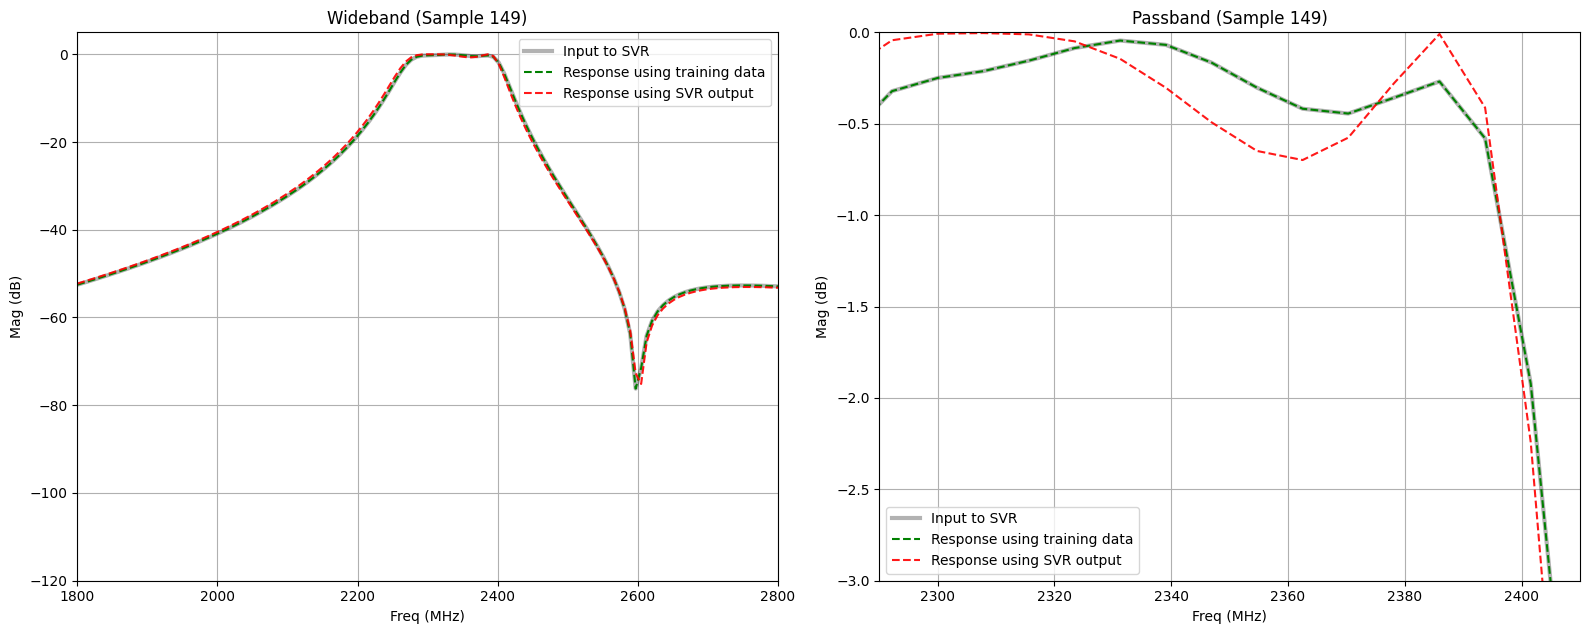

In [15]:
# Evaluate on a single sample of trained SVR, saving data and plots together

# number of points in frequency response of network
N_FreqResp=129
FreqVec_MHz=np.linspace(1800,2800,N_FreqResp)

# Select a single index from the test set
sample_idx = 149 # Change this to any valid index < len(X_test_raw)

# Setup the matplotlib figure for 1 row and 2 columns for side-by-side display
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Get the raw input and target for this sample
input_sample_raw = X_test_raw[sample_idx]

# Inverse log10 transform the actual target since y_test_raw is in log10 space
target_sample_raw = 10 ** (y_test_raw[sample_idx])

# 1. Preprocess the input using SVR scalers
input_sample_scaled = loaded_scaler_X_svr.transform(input_sample_raw.reshape(1, -1))

# 2. Run Inference with SVR
prediction_scaled_np = loaded_svr_model.predict(input_sample_scaled)

# 3. Inverse Transform to get physical units
prediction_log = loaded_scaler_y_svr.inverse_transform(prediction_scaled_np.reshape(1, -1)).flatten()
prediction_raw = 10 ** prediction_log

# 4. Calculate Error
relative_error = np.abs((prediction_raw - target_sample_raw) / (target_sample_raw + 1e-9)) * 100

# 5. Create Comparison Table
results_df = pd.DataFrame({
    'Component': output_cols,
    'Training Data': target_sample_raw,
    'SVR Output': prediction_raw,
    'Err(%)': relative_error
})

# Verify Prediction by Resimulation
L_pred, Cs_pred, Cp_pred = np.zeros(3), np.zeros(3), np.zeros(3)
L_act, Cs_act, Cp_act = np.zeros(3), np.zeros(3), np.zeros(3)

# Map flat arrays to structured arrays
for j, col_name in enumerate(output_cols):
    val_pred = prediction_raw[j]
    val_act = target_sample_raw[j]
    if col_name.startswith('L_'):
        idx = int(col_name.split('_')[1])
        L_pred[idx], L_act[idx] = val_pred, val_act
    elif col_name.startswith('Cs_'):
        idx = int(col_name.split('_')[1])
        Cs_pred[idx], Cs_act[idx] = val_pred, val_act
    elif col_name.startswith('Cp_'):
        idx = int(col_name.split('_')[1])
        Cp_pred[idx], Cp_act[idx] = val_pred, val_act

# 2. Run AC Simulation
pred_mag_resp = ACsim(L_pred, Cs_pred, Cp_pred, FreqVec_MHz, render_mode=False)
act_mag_resp = ACsim(L_act, Cs_act, Cp_act, FreqVec_MHz, render_mode=False)

mape_act = np.mean(np.abs((input_sample_raw - act_mag_resp) / (np.abs(input_sample_raw) + 1e-8))) * 100
mape_pred = np.mean(np.abs((input_sample_raw - pred_mag_resp) / (np.abs(input_sample_raw) + 1e-8))) * 100

# ---- COL 0: Wideband Plot ----
ax_wide = axes[0]
ax_wide.plot(FreqVec_MHz, input_sample_raw, label='Input to SVR', color='black', linewidth=3, alpha=0.3)
ax_wide.plot(FreqVec_MHz, act_mag_resp, label='Response using training data', color='green', linewidth=1.5, linestyle='--')
ax_wide.plot(FreqVec_MHz, pred_mag_resp, label='Response using SVR output', color='red', linewidth=1.5, linestyle='--', alpha=0.9)
ax_wide.set_title(f"Wideband (Sample {sample_idx})")
ax_wide.set_xlabel("Freq (MHz)")
ax_wide.set_ylabel("Mag (dB)")
ax_wide.grid(True, which="both")
ax_wide.set_ylim(-120, 5)
ax_wide.set_xlim(val_Freq_lo, val_Freq_hi)
ax_wide.legend()

# ---- COL 1: Passband Plot ----
ax_pass = axes[1]
ax_pass.plot(FreqVec_MHz, input_sample_raw, label='Input to SVR', color='black', linewidth=3, alpha=0.3)
ax_pass.plot(FreqVec_MHz, act_mag_resp, label='Response using training data', color='green', linewidth=1.5, linestyle='--')
ax_pass.plot(FreqVec_MHz, pred_mag_resp, label='Response using SVR output', color='red', linewidth=1.5, linestyle='--', alpha=0.9)
ax_pass.set_title(f"Passband (Sample {sample_idx})")
ax_pass.set_xlabel("Freq (MHz)")
ax_pass.set_ylabel("Mag (dB)")
ax_pass.grid(True, which="both")
ax_pass.set_ylim(-3, 0)
ax_pass.set_xlim(2290, 2410)
ax_pass.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95], w_pad=1.5)
plt.show()

<font color="blue"> **Step 8c:** Evaluation of SVR on new data that it has not seen during training. Optimize the SVR inference to see  how sub-optimal it is.

Starting post-inference optimization for a single  profile...
Optimization done in 1.94 seconds
Response MSE (SVR): 261.50 | Response Opt MSE : 244.53
Component MAPE (SVR vs Opt): 9.2790%



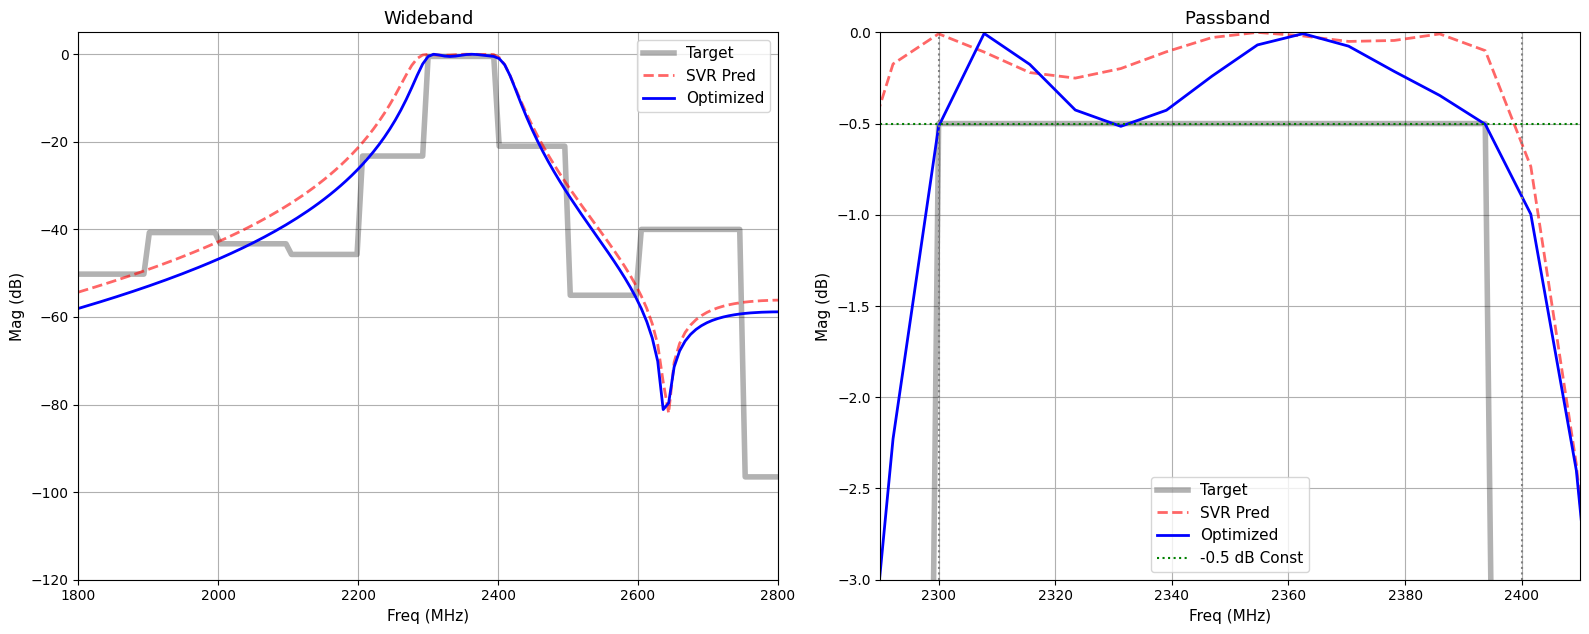

In [16]:
print(f"Starting post-inference optimization for a single  profile...")
profile_index = 159
# Setup the matplotlib figure for 1 row and 2 columns for side-by-side display
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
all_profile_cols = [c for c in df_piecewise.columns if c != 'FreqVec_MHz']
prof_name = all_profile_cols[profile_index]
input_sample_raw = df_piecewise[prof_name].values

# 1. Passband limits
pb_low, pb_high = 2300, 2400
passband_idx = np.where((FreqVec_MHz >= pb_low) & (FreqVec_MHz <= pb_high))[0]

# 2. Get SVR Prediction (Initial Guess)
input_sample_scaled = loaded_scaler_X_svr.transform(input_sample_raw.reshape(1, -1))
prediction_scaled_np = loaded_svr_model.predict(input_sample_scaled)

prediction_log = loaded_scaler_y_svr.inverse_transform(prediction_scaled_np.reshape(1, -1)).flatten()
prediction_raw = 10 ** prediction_log

# Map predictions to components
L_pred, Cs_pred, Cp_pred = np.zeros(3), np.zeros(3), np.zeros(3)
for j, col_name in enumerate(output_cols):
    val_pred = prediction_raw[j]
    if col_name.startswith('L_'): L_pred[int(col_name.split('_')[1])] = val_pred
    elif col_name.startswith('Cs_'): Cs_pred[int(col_name.split('_')[1])] = val_pred
    elif col_name.startswith('Cp_'): Cp_pred[int(col_name.split('_')[1])] = val_pred

pred_mag_resp = ACsim(L_pred, Cs_pred, Cp_pred, FreqVec_MHz, render_mode=False)

# 3. Define Objective Function for this specific profile
def optimize_filter(params):
    # Unpack parameters, use absolute value to prevent negative components
    params = np.abs(params)
    L_opt = params[0:3]
    Cs_opt = params[3:6]
    Cp_opt = params[6:9]

    # Simulate the circuit
    mag = ACsim(L_opt, Cs_opt, Cp_opt, FreqVec_MHz, render_mode=False)

    # Passband Constraint: Magnitude must be >= -0.5 dB
    passband_mag = mag[passband_idx]
    passband_penalty = np.sum(np.maximum(-0.5 - passband_mag, 0)**2) * in_band_weight_Opt

    # Overall Shape: Keep the rest of the response as close to the target as possible
    shape_error = np.mean((mag - input_sample_raw)**2)

    return shape_error + passband_penalty

# 4. Run Optimization
start_time = time.time()
initial_params = np.concatenate((L_pred, Cs_pred, Cp_pred))
res = minimize(optimize_filter, initial_params, method='Nelder-Mead', options={'maxiter': 500})
opt_duration = time.time() - start_time

# Extract and ensure positive values
opt_params = np.abs(res.x)
L_opt = opt_params[0:3]
Cs_opt = opt_params[3:6]
Cp_opt = opt_params[6:9]

opt_mag_resp = ACsim(L_opt, Cs_opt, Cp_opt, FreqVec_MHz, render_mode=False)

mse_svr = np.mean((input_sample_raw - pred_mag_resp)**2)
msr_opt = np.mean((input_sample_raw - opt_mag_resp)**2)

# Calculate MAPE for components (SVR vs Optimized)
mape_comp = np.mean(np.abs((opt_params - initial_params) / (np.abs(initial_params) + 1e-8))) * 100

print(f"Optimization done in {opt_duration:.2f} seconds")
print(f"Response MSE (SVR): {mse_svr:.2f} | Response Opt MSE : {msr_opt:.2f}")
print(f"Component MAPE (SVR vs Opt): {mape_comp:.4f}%\n")

# ---- COL 0: Wideband Plot ----
ax_wide = axes[0]
ax_wide.plot(FreqVec_MHz, input_sample_raw, label='Target', color='black', linewidth=4, alpha=0.3)
ax_wide.plot(FreqVec_MHz, pred_mag_resp, label='SVR Pred', color='red', linewidth=2, linestyle='--', alpha=0.6)
ax_wide.plot(FreqVec_MHz, opt_mag_resp, label='Optimized', color='blue', linewidth=2)
ax_wide.set_title(f"Wideband", fontsize=13)
ax_wide.set_xlabel("Freq (MHz)", fontsize=11)
ax_wide.set_ylabel("Mag (dB)", fontsize=11)
ax_wide.grid(True, which="both")
ax_wide.set_ylim(-120, 5)
ax_wide.set_xlim(val_Freq_lo, val_Freq_hi)
ax_wide.legend(fontsize=11)

# ---- COL 1: Passband Plot ----
ax_pass = axes[1]
ax_pass.plot(FreqVec_MHz, input_sample_raw, label='Target', color='black', linewidth=4, alpha=0.3)
ax_pass.plot(FreqVec_MHz, pred_mag_resp, label='SVR Pred', color='red', linewidth=2, linestyle='--', alpha=0.6)
ax_pass.plot(FreqVec_MHz, opt_mag_resp, label='Optimized', color='blue', linewidth=2)

# Constraints
ax_pass.axhline(-0.5, color='green', linestyle=':', label='-0.5 dB Const')
ax_pass.axvline(pb_low, color='gray', linestyle=':')
ax_pass.axvline(pb_high, color='gray', linestyle=':')

ax_pass.set_title(f"Passband ", fontsize=13)
ax_pass.set_xlabel("Freq (MHz)", fontsize=11)
ax_pass.set_ylabel("Mag (dB)", fontsize=11)
ax_pass.grid(True, which="both")
ax_pass.set_ylim(-3, 0)
ax_pass.set_xlim(pb_low - 10, pb_high + 10)
ax_pass.legend(fontsize=11)

# Adjust spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95], w_pad=1.5)

# Save the combined figure as a PNG file
file_name = f'optimized_goal_comparison_{prof_name.replace(" ", "_")}.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

<font color="blue"> **Step 8d:** Comparing SVR inference with optimized design averaged over 100 cases  

In [17]:
import random
import time
from scipy.optimize import minimize

print("Evaluating SVR performance and Optimization on 100 piecewise filter profiles...")

# Get all profile columns except 'FreqVec_MHz'
all_profile_cols = [col for col in df_piecewise.columns if col != 'FreqVec_MHz']

# Randomly select 100 profiles
random.seed(42) # for reproducibility
selected_profile_cols = random.sample(all_profile_cols, 100)

all_mses = []
all_opt_mses = []

# Passband limits for optimization
pb_low, pb_high = 2300, 2400
passband_idx = np.where((FreqVec_MHz >= pb_low) & (FreqVec_MHz <= pb_high))[0]

start_eval_time = time.time()

for i, prof_name in enumerate(selected_profile_cols):
    if (i + 1) % 10 == 0:
       print(f"Processed {i + 1}/{len(selected_profile_cols)} profiles...")

    input_sample_raw = df_piecewise[prof_name].values

    # 1. Preprocess the input
    input_sample_scaled = loaded_scaler_X_svr.transform(input_sample_raw.reshape(1, -1))

    # 2. Run Inference
    prediction_scaled_np = loaded_svr_model.predict(input_sample_scaled)

    # 3. Inverse Transform to get physical units
    prediction_log = loaded_scaler_y_svr.inverse_transform(prediction_scaled_np).flatten()
    prediction_raw = 10 ** prediction_log

    # Parse predicted values back into arrays for ACsim
    L_pred = np.zeros(3)
    Cs_pred = np.zeros(3)
    Cp_pred = np.zeros(3)

    for j, col_name in enumerate(output_cols):
        val_pred = prediction_raw[j]
        if col_name.startswith('L_'):
            idx = int(col_name.split('_')[1])
            L_pred[idx] = val_pred
        elif col_name.startswith('Cs_'):
            idx = int(col_name.split('_')[1])
            Cs_pred[idx] = val_pred
        elif col_name.startswith('Cp_'):
            idx = int(col_name.split('_')[1])
            Cp_pred[idx] = val_pred

    # 4. Run AC Simulation with SVR outputs
    pred_mag_resp = ACsim(L_pred, Cs_pred, Cp_pred, FreqVec_MHz, render_mode=False)

    # 5. Calculate MSE for this sample
    mse_pred = np.mean((input_sample_raw - pred_mag_resp)**2)
    all_mses.append(mse_pred)

    # 6. Run Optimization
    def optimize_filter(params):
        params = np.abs(params)
        L_opt = params[0:3]
        Cs_opt = params[3:6]
        Cp_opt = params[6:9]

        mag = ACsim(L_opt, Cs_opt, Cp_opt, FreqVec_MHz, render_mode=False)

        passband_mag = mag[passband_idx]
        passband_penalty = np.sum(np.maximum(-0.5 - passband_mag, 0)**2) * in_band_weight_Opt
        shape_error = np.mean((mag - input_sample_raw)**2)
        return shape_error + passband_penalty

    initial_params = np.concatenate((L_pred, Cs_pred, Cp_pred))
    res = minimize(optimize_filter, initial_params, method='Nelder-Mead', options={'maxiter': 500})

    opt_params = np.abs(res.x)
    L_opt = opt_params[0:3]
    Cs_opt = opt_params[3:6]
    Cp_opt = opt_params[6:9]

    opt_mag_resp = ACsim(L_opt, Cs_opt, Cp_opt, FreqVec_MHz, render_mode=False)
    mse_opt = np.mean((input_sample_raw - opt_mag_resp)**2)
    all_opt_mses.append(mse_opt)

eval_duration = time.time() - start_eval_time

# Calculate and report the average MSE
average_mse = np.mean(all_mses)
average_opt_mse = np.mean(all_opt_mses)

print(f"\nEvaluation and Optimization Complete for {len(selected_profile_cols)} samples in {eval_duration:.2f} seconds.")
print(f"Average Response MSE (SVR): {average_mse:.4f}")
print(f"Average Response MSE (Optimized): {average_opt_mse:.4f}")

Evaluating SVR performance and Optimization on 100 piecewise filter profiles...
Processed 10/100 profiles...
Processed 20/100 profiles...
Processed 30/100 profiles...
Processed 40/100 profiles...
Processed 50/100 profiles...
Processed 60/100 profiles...
Processed 70/100 profiles...
Processed 80/100 profiles...
Processed 90/100 profiles...
Processed 100/100 profiles...

Evaluation and Optimization Complete for 100 samples in 199.38 seconds.
Average Response MSE (SVR): 620.0630
Average Response MSE (Optimized): 523.0637
